# Retrieval vs Ranking Toy

## Роль notebook

Это короткий toy-notebook про двухстадийный pipeline. Его задача не в том, чтобы обучить ещё одну большую модель, а в том, чтобы визуально отделить две разные стадии рекомендательной системы:

- `retrieval` находит небольшой shortlist кандидатов;
- `ranking` переупорядочивает этот shortlist более точным score.


## Зачем этот шаг после `two-tower`

В `03_two_tower_model_intro.ipynb` мы уже увидели retrieval-мышление: модель не обязана сразу строить финальную выдачу, она может сначала быстро найти кандидатов.

В `04_sequence_recommender_intro.ipynb` мы временно ушли в другую advanced-ветку и посмотрели, как меняется задача, когда важен порядок событий пользователя.

Теперь мы возвращаемся к retrieval-линии и добавляем следующий системный шаг: понять, почему хороший retrieval ещё не гарантирует хороший финальный список. Если релевантный объект уже попал в shortlist, ranking может поднять его выше. Если retrieval его вообще не нашёл, ranking уже не спасёт.


## План

- собрать маленький синтетический каталог и несколько user-запросов;
- задать coarse retrieval-score;
- задать richer ranking-score с дополнительными признаками;
- сравнить candidate recall retrieval-стадии и ranking-метрики до/после reranking;
- отдельно зафиксировать, какие features для ranking были бы leakage.


In [1]:
import os
import tempfile

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mplconfig_"))

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from recsys_basics.metrics import evaluate_ranking_metrics

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")


Matplotlib is building the font cache; this may take a moment.


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero
SRC_DIR: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/src


## Toy-данные

Ниже нет реальных логов и real-time serving. Мы специально делаем маленький искусственный пример, чтобы было видно, зачем ranking вообще нужен поверх retrieval.


In [2]:
sessions_df = pd.DataFrame(
    [
        {"user_id": 1, "need_tag": "dry_skin", "category": "skincare", "preferred_brand": "A", "preferred_price": "budget", "novelty_pref": 0.20},
        {"user_id": 2, "need_tag": "curly_hair", "category": "haircare", "preferred_brand": "B", "preferred_price": "mid", "novelty_pref": 0.80},
        {"user_id": 3, "need_tag": "acne", "category": "skincare", "preferred_brand": "C", "preferred_price": "budget", "novelty_pref": 0.50},
        {"user_id": 4, "need_tag": "red_lip", "category": "makeup", "preferred_brand": "A", "preferred_price": "premium", "novelty_pref": 0.30},
        {"user_id": 5, "need_tag": "anti_age", "category": "skincare", "preferred_brand": "D", "preferred_price": "premium", "novelty_pref": 0.70},
        {"user_id": 6, "need_tag": "damaged_hair", "category": "haircare", "preferred_brand": "B", "preferred_price": "mid", "novelty_pref": 0.40},
    ]
)

items_df = pd.DataFrame(
    [
        {"item_id": 101, "title": "Aqua Gel", "need_tag": "dry_skin", "category": "skincare", "brand": "A", "price_band": "budget", "popularity": 0.95, "freshness": 0.30, "margin": 0.40},
        {"item_id": 102, "title": "Barrier Cream", "need_tag": "dry_skin", "category": "skincare", "brand": "A", "price_band": "mid", "popularity": 0.70, "freshness": 0.85, "margin": 0.50},
        {"item_id": 103, "title": "Acne Spot", "need_tag": "acne", "category": "skincare", "brand": "C", "price_band": "budget", "popularity": 0.55, "freshness": 0.80, "margin": 0.45},
        {"item_id": 104, "title": "Retinol Night", "need_tag": "anti_age", "category": "skincare", "brand": "D", "price_band": "premium", "popularity": 0.60, "freshness": 0.90, "margin": 0.55},
        {"item_id": 105, "title": "Vitamin Serum", "need_tag": "anti_age", "category": "skincare", "brand": "A", "price_band": "premium", "popularity": 0.92, "freshness": 0.60, "margin": 0.60},
        {"item_id": 106, "title": "Curl Definer", "need_tag": "curly_hair", "category": "haircare", "brand": "B", "price_band": "mid", "popularity": 0.68, "freshness": 0.88, "margin": 0.42},
        {"item_id": 107, "title": "Repair Mask", "need_tag": "damaged_hair", "category": "haircare", "brand": "B", "price_band": "mid", "popularity": 0.83, "freshness": 0.45, "margin": 0.52},
        {"item_id": 108, "title": "Volume Spray", "need_tag": "curly_hair", "category": "haircare", "brand": "C", "price_band": "budget", "popularity": 0.90, "freshness": 0.50, "margin": 0.38},
        {"item_id": 109, "title": "Red Lip Velvet", "need_tag": "red_lip", "category": "makeup", "brand": "A", "price_band": "premium", "popularity": 0.66, "freshness": 0.75, "margin": 0.58},
        {"item_id": 110, "title": "Red Lip Matte", "need_tag": "red_lip", "category": "makeup", "brand": "D", "price_band": "mid", "popularity": 0.91, "freshness": 0.40, "margin": 0.62},
        {"item_id": 111, "title": "Gloss Shine", "need_tag": "red_lip", "category": "makeup", "brand": "A", "price_band": "budget", "popularity": 0.88, "freshness": 0.65, "margin": 0.35},
        {"item_id": 112, "title": "Daily Cleanser", "need_tag": "acne", "category": "skincare", "brand": "B", "price_band": "budget", "popularity": 0.97, "freshness": 0.25, "margin": 0.70},
    ]
)

print("Requests:")
display(sessions_df)
print("Catalog:")
display(items_df)


Requests:


,user_id,need_tag,category,preferred_brand,preferred_price,novelty_pref
0,1,dry_skin,skincare,A,budget,0.2000
1,2,curly_hair,haircare,B,mid,0.8000
2,3,acne,skincare,C,budget,0.5000
3,4,red_lip,makeup,A,premium,0.3000
4,5,anti_age,skincare,D,premium,0.7000
5,6,damaged_hair,haircare,B,mid,0.4000


Catalog:


,item_id,title,need_tag,category,brand,price_band,popularity,freshness,margin
0,101,Aqua Gel,dry_skin,skincare,A,budget,0.9500,0.3000,0.4000
1,102,Barrier Cream,dry_skin,skincare,A,mid,0.7000,0.8500,0.5000
2,103,Acne Spot,acne,skincare,C,budget,0.5500,0.8000,0.4500
3,104,Retinol Night,anti_age,skincare,D,premium,0.6000,0.9000,0.5500
4,105,Vitamin Serum,anti_age,skincare,A,premium,0.9200,0.6000,0.6000
5,106,Curl Definer,curly_hair,haircare,B,mid,0.6800,0.8800,0.4200
6,107,Repair Mask,damaged_hair,haircare,B,mid,0.8300,0.4500,0.5200
7,108,Volume Spray,curly_hair,haircare,C,budget,0.9000,0.5000,0.3800
8,109,Red Lip Velvet,red_lip,makeup,A,premium,0.6600,0.7500,0.5800
9,110,Red Lip Matte,red_lip,makeup,D,mid,0.9100,0.4000,0.6200


## Как устроен toy-сценарий

Мы зададим три разных score:

- `true_score` — скрытая "истинная" полезность объекта для данного запроса; по нему определяется один relevant item на пользователя;
- `retrieval_score` — грубый быстрый score, который знает только category, topical match и popularity;
- `ranking_score` — более точный score, который уже использует brand match, price fit и freshness fit.

Идея ровно в этом: retrieval работает быстро и грубо, ranking — медленнее, но точнее на уже маленьком shortlist.


In [3]:
PRICE_ORDER = {"budget": 0, "mid": 1, "premium": 2}
RETRIEVAL_K = 5


def build_feature_frame(sessions: pd.DataFrame, items: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for session in sessions.to_dict("records"):
        for item in items.to_dict("records"):
            category_match = float(session["category"] == item["category"])
            need_match = float(session["need_tag"] == item["need_tag"])
            brand_match = float(session["preferred_brand"] == item["brand"])
            price_fit = 1 - abs(PRICE_ORDER[session["preferred_price"]] - PRICE_ORDER[item["price_band"]]) / 2
            freshness_fit = 1 - abs(session["novelty_pref"] - item["freshness"])

            retrieval_score = 1.8 * category_match + 1.4 * need_match + 0.8 * item["popularity"]
            true_score = (
                1.4 * category_match
                + 1.3 * need_match
                + 1.0 * brand_match
                + 0.9 * price_fit
                + 0.8 * freshness_fit
                + 0.1 * item["popularity"]
            )
            ranking_score = 0.55 * retrieval_score + 0.9 * brand_match + 0.7 * price_fit + 0.6 * freshness_fit

            rows.append(
                {
                    "user_id": session["user_id"],
                    "need_tag": session["need_tag"],
                    "preferred_brand": session["preferred_brand"],
                    "preferred_price": session["preferred_price"],
                    "item_id": item["item_id"],
                    "title": item["title"],
                    "category": item["category"],
                    "brand": item["brand"],
                    "price_band": item["price_band"],
                    "category_match": category_match,
                    "need_match": need_match,
                    "brand_match": brand_match,
                    "price_fit": price_fit,
                    "freshness_fit": freshness_fit,
                    "popularity": item["popularity"],
                    "retrieval_score": retrieval_score,
                    "ranking_score": ranking_score,
                    "true_score": true_score,
                }
            )
    return pd.DataFrame(rows)


full_df = build_feature_frame(sessions_df, items_df)

ground_truth_df = (
    full_df.sort_values(["user_id", "true_score", "item_id"], ascending=[True, False, True])
    .groupby("user_id")
    .head(1)
    .loc[:, ["user_id", "item_id", "title", "true_score"]]
    .reset_index(drop=True)
)

full_df = full_df.merge(
    ground_truth_df.loc[:, ["user_id", "item_id"]].assign(label=1),
    on=["user_id", "item_id"],
    how="left",
)
full_df["label"] = full_df["label"].fillna(0).astype(int)

print("Hidden relevant item for each request:")
display(ground_truth_df)


Hidden relevant item for each request:


,user_id,item_id,title,true_score
0,1,101,Aqua Gel,5.4150
1,2,106,Curl Definer,5.4040
2,3,103,Acne Spot,5.2150
3,4,109,Red Lip Velvet,5.1060
4,5,104,Retinol Night,5.3000
5,6,107,Repair Mask,5.4430


In [4]:
retrieval_candidates_df = (
    full_df.sort_values(["user_id", "retrieval_score", "item_id"], ascending=[True, False, True])
    .groupby("user_id")
    .head(RETRIEVAL_K)
    .reset_index(drop=True)
)

candidate_recall_at_5 = retrieval_candidates_df.groupby("user_id")["label"].max().mean()
retrieval_stage_summary = pd.DataFrame(
    [
        {"metric": "requests", "value": sessions_df["user_id"].nunique()},
        {"metric": "catalog_size", "value": items_df["item_id"].nunique()},
        {"metric": "retrieval_k", "value": RETRIEVAL_K},
        {"metric": "candidate_recall@5", "value": round(candidate_recall_at_5, 4)},
    ]
)

display(retrieval_stage_summary)


,metric,value
0,requests,6.0000
1,catalog_size,12.0000
2,retrieval_k,5.0000
3,candidate_recall@5,1.0000


## Что уже показывает retrieval

Здесь retrieval оценивается не по финальному порядку, а по более грубому вопросу: попал ли relevant item в shortlist вообще.

Если `candidate_recall@5` низкий, ranking ничего не исправит: он просто не увидит нужный объект. Если `candidate_recall@5` высокий, тогда уже имеет смысл обсуждать качество финального порядка внутри shortlist.


In [5]:
sample_user_id = 5
sample_candidates_df = retrieval_candidates_df[retrieval_candidates_df["user_id"] == sample_user_id].copy()

print(f"Sample request user_id = {sample_user_id}")
display(
    sample_candidates_df[
        [
            "item_id",
            "title",
            "brand",
            "price_band",
            "retrieval_score",
            "brand_match",
            "price_fit",
            "freshness_fit",
            "ranking_score",
            "label",
        ]
    ].sort_values(["retrieval_score", "item_id"], ascending=[False, True])
)


Sample request user_id = 5


,item_id,title,brand,price_band,retrieval_score,brand_match,price_fit,freshness_fit,ranking_score,label
20,105,Vitamin Serum,A,premium,3.9360,0.0000,1.0000,0.9000,3.4048,0
21,104,Retinol Night,D,premium,3.6800,1.0000,1.0000,0.8000,4.1040,1
22,112,Daily Cleanser,B,budget,2.5760,0.0000,0.0000,0.5500,1.7468,0
23,101,Aqua Gel,A,budget,2.5600,0.0000,0.0000,0.6000,1.7680,0
24,102,Barrier Cream,A,mid,2.3600,0.0000,0.5000,0.8500,2.1580,0


In [6]:
def build_ranked_recommendations(candidates: pd.DataFrame, score_column: str) -> pd.DataFrame:
    ranked = candidates.sort_values(["user_id", score_column, "item_id"], ascending=[True, False, True]).copy()
    ranked["rank"] = ranked.groupby("user_id").cumcount() + 1
    return ranked[["user_id", "item_id", "rank", score_column]].rename(columns={score_column: "score"})


retrieval_recommendations_df = build_ranked_recommendations(retrieval_candidates_df, "retrieval_score")
reranked_recommendations_df = build_ranked_recommendations(retrieval_candidates_df, "ranking_score")

sample_comparison_df = (
    retrieval_recommendations_df[retrieval_recommendations_df["user_id"] == sample_user_id]
    .rename(columns={"rank": "retrieval_rank", "score": "retrieval_score_sorted"})
    .merge(
        reranked_recommendations_df[reranked_recommendations_df["user_id"] == sample_user_id]
        .rename(columns={"rank": "ranking_rank", "score": "ranking_score_sorted"}),
        on=["user_id", "item_id"],
        how="inner",
    )
    .merge(
        retrieval_candidates_df[["user_id", "item_id", "title", "brand_match", "price_fit", "freshness_fit", "label"]],
        on=["user_id", "item_id"],
        how="left",
    )
    .sort_values(["retrieval_rank", "item_id"])
)

print("How ranking reorders the same shortlist:")
display(sample_comparison_df)


How ranking reorders the same shortlist:


,user_id,item_id,retrieval_rank,retrieval_score_sorted,ranking_rank,ranking_score_sorted,title,brand_match,price_fit,freshness_fit,label
0,5,105,1,3.9360,2,3.4048,Vitamin Serum,0.0000,1.0000,0.9000,0
1,5,104,2,3.6800,1,4.1040,Retinol Night,1.0000,1.0000,0.8000,1
2,5,112,3,2.5760,5,1.7468,Daily Cleanser,0.0000,0.0000,0.5500,0
3,5,101,4,2.5600,4,1.7680,Aqua Gel,0.0000,0.0000,0.6000,0
4,5,102,5,2.3600,3,2.1580,Barrier Cream,0.0000,0.5000,0.8500,0


In [7]:
def mean_metrics_at_k(test_df: pd.DataFrame, recommendations: pd.DataFrame, k: int) -> dict[str, float]:
    metrics_df = evaluate_ranking_metrics(test_df, recommendations[["user_id", "item_id", "rank"]], k=k)
    return {
        column: round(float(metrics_df[column].mean()), 4)
        for column in metrics_df.columns
        if column != "user_id"
    }


eval_df = ground_truth_df[["user_id", "item_id"]].copy()
retrieval_at_1 = mean_metrics_at_k(eval_df, retrieval_recommendations_df, k=1)
retrieval_at_3 = mean_metrics_at_k(eval_df, retrieval_recommendations_df, k=3)
reranking_at_1 = mean_metrics_at_k(eval_df, reranked_recommendations_df, k=1)
reranking_at_3 = mean_metrics_at_k(eval_df, reranked_recommendations_df, k=3)

metrics_summary = pd.DataFrame(
    [
        {
            "model": "retrieval_order",
            "candidate_recall@5": round(candidate_recall_at_5, 4),
            "hit_rate@1": retrieval_at_1["hit_rate@1"],
            "map@3": retrieval_at_3["map@3"],
            "ndcg@3": retrieval_at_3["ndcg@3"],
        },
        {
            "model": "reranking",
            "candidate_recall@5": round(candidate_recall_at_5, 4),
            "hit_rate@1": reranking_at_1["hit_rate@1"],
            "map@3": reranking_at_3["map@3"],
            "ndcg@3": reranking_at_3["ndcg@3"],
        },
    ]
)

display(metrics_summary)


,model,candidate_recall@5,hit_rate@1,map@3,ndcg@3
0,retrieval_order,1.0000,0.3333,0.6389,0.7321
1,reranking,1.0000,1.0000,1.0000,1.0000


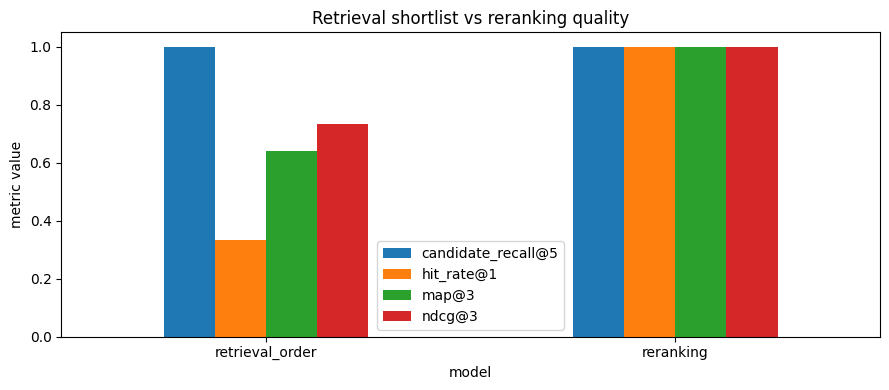

In [8]:
plot_df = metrics_summary.set_index("model")[["candidate_recall@5", "hit_rate@1", "map@3", "ndcg@3"]]
ax = plot_df.plot(kind="bar", figsize=(9, 4), rot=0)
ax.set_title("Retrieval shortlist vs reranking quality")
ax.set_ylabel("metric value")
plt.tight_layout()
plt.show()


## Как интерпретировать результат

В этом toy-примере retrieval уже делает важную часть работы: `candidate_recall@5 = 1.0`, то есть для всех запросов relevant item попал в shortlist.

Но финальный порядок у retrieval всё ещё слабый. В текущем прогоне `hit_rate@1` у грубого retrieval-порядка равен `0.3333`, а после reranking становится `1.0`. По `MAP@3` и `NDCG@3` тоже видно, что richer ranking-features улучшают порядок внутри того же самого shortlist.

При этом важно не переинтерпретировать цифры. Здесь почти идеальный результат reranking получен не потому, что мы построили "сильную production-модель", а потому что toy-сценарий специально сконструирован так, чтобы показать сам принцип двух стадий.

Главный учебный вывод:

- retrieval отвечает на вопрос: "кого вообще пустить в следующий этап?";
- ranking отвечает на вопрос: "в каком порядке показать этих кандидатов?";
- ranking может сильно улучшить порядок, если retrieval уже принёс правильный объект;
- ranking не может восстановить объект, который retrieval не принёс;
- поэтому в многостадийной системе нужны обе проверки: candidate recall на входе ranking-слоя и quality-метрики на выходе.


## Про leakage в ranking-features

В ranking-слое особенно опасны признаки, которые содержат информацию из будущего или напрямую кодируют target.

Нормальные признаки в духе этого toy-примера:

- `retrieval_score`;
- `brand_match`;
- `price_fit`;
- `freshness_fit`;
- агрегаты из прошлой истории пользователя и объекта.

Плохие признаки:

- `clicked_in_next_24h`;
- `purchased_after_recommendation`;
- `final_position_after_manual_rerank`;
- любые post-event логи, которые появляются только после показа рекомендации.

Если такой leakage попадает в обучение, offline-метрики становятся искусственно высокими. В toy-notebook это особенно легко не заметить, потому что пример маленький и полностью контролируемый, поэтому сам принцип leakage лучше проговорить прямо.


## Что дальше

Следующий шаг в маршруте: [06_production_overview.md](../../docs/advanced/06_production_overview.md).
